<a href="https://colab.research.google.com/github/tor-apiwit/var_risk_engine/blob/main/var_risk_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Portfolio Value at Risk (VaR) Engine

Computes portfolio VaR using three methods — **Parametric (Variance-Covariance)**, **Historical**, and **Monte Carlo** — finds the portfolio weights that minimize risk / minimize tail loss via constrained optimization, and runs a rolling 1-year backtest to see how VaR changes over time.

## 1. Setup

Import library:
- `yfinance`
- `numpy`, `pandas`
- `scipy.stats.norm`
- `scipy.optimize.minimize`


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize
from scipy.stats import norm,chi2

## 2. Config

All constants are defined rather than scattered as "magic numbers" throughout the notebook, so a single parameter change propagates everywhere it's used.

**Scaling convention** (used consistently throughout): volatility scales with `sqrt(horizon)`, variance/covariance scales with `horizon` — consistent with the i.i.d. daily returns assumption.

In [ ]:
from datetime import datetime
today = datetime.today()
# END_DATE = today.strftime("%Y-%m-%d")

In [ ]:
# ---------------------------------------------------------------------------
# Universe & data window
# ---------------------------------------------------------------------------
TICKERS = ["NVDA", "AAL", "META", "TSLA", "ASML"]
START_DATE = "2015-12-31"
END_DATE = "2025-12-31"

# ---------------------------------------------------------------------------
# Initial portfolio weights (must be in the same order as TICKERS)
# ---------------------------------------------------------------------------
W_PORT_INITIAL = np.array([1/5, 1/5, 1/5, 1/5, 1/5])

# ---------------------------------------------------------------------------
# Risk parameters
# ---------------------------------------------------------------------------
INVESTMENT_HORIZON = 5      # in trading days, used by the static VaR section
CONFIDENCE = 0.95           # e.g. 0.95 -> 95% VaR

# ---------------------------------------------------------------------------
# Rolling window backtest
# ---------------------------------------------------------------------------
ROLLING_WINDOW = 252        # trading days used to estimate mu/sigma per window
N_ROLLING_WINDOWS = 252     # number of windows to compute (stepped by 1 day)

## 3. Load Price Data and Compute Returns

**`load_close_prices`**: fetches each ticker's daily close price from Yahoo Finance and merges them into a single DataFrame.

Each ticker is wrapped in its own try/except — if a given ticker cannot be fetched (e.g. delisted, or rate-limited), the code prints a warning and skips it instead of crashing the whole script.

**`compute_returns`**: computes
- **Daily log return**: `ln(P_t / P_{t-1})` — log returns are used because they are additive across time.
- **Annual simple return**: uses year-end close prices, simple return `(P_t/P_{t-1}) - 1`, to show a yearly overview of performance.


In [ ]:
def load_close_prices(tickers: list[str], start: str, end: str) -> pd.DataFrame:
  """
  Fetch each ticker's daily close price and merge into one DataFrame.
  """
  series_list = []
  for ticker in tickers:
    close = yf.Ticker(ticker).history(start=start, end=end, interval="1d")["Close"]
    close.name = ticker
    series_list.append(close)
    prices = pd.concat(series_list, axis=1)
  return prices

def compute_returns(close_prices: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:

  """
  Compute daily log returns and annual simple returns.
  """
  returns_daily = np.log(close_prices / close_prices.shift(1)).dropna()
  annual_close = close_prices.resample("YE").last()
  returns_annual = (annual_close / annual_close.shift(1) - 1).dropna()
  return returns_daily, returns_annual

In [ ]:
close_prices = load_close_prices(TICKERS, START_DATE, END_DATE)
returns_daily, returns_annual = compute_returns(close_prices)
returns_daily

,NVDA,AAL,META,TSLA,ASML
Date,,,,,
2016-01-04 00:00:00-05:00,-0.018063,-0.034594,-0.023590,-0.071672,-0.016698
2016-01-05 00:00:00-05:00,0.015937,-0.009579,0.004977,0.000090,-0.010131
2016-01-06 00:00:00-05:00,-0.042229,0.017371,0.002333,-0.019844,-0.021167
2016-01-07 00:00:00-05:00,-0.040452,-0.019100,-0.050287,-0.015598,-0.025375
2016-01-08 00:00:00-05:00,-0.021700,-0.001980,-0.006044,-0.021799,-0.027157
...,...,...,...,...,...
2025-12-23 00:00:00-05:00,0.029608,-0.041437,0.005187,-0.006507,0.004587
2025-12-24 00:00:00-05:00,-0.003176,0.005115,0.003918,-0.000330,0.003460
2025-12-26 00:00:00-05:00,0.010128,-0.015425,-0.006402,-0.021259,0.006762


## 4. Portfolio Statistics (Consistent Scaling)

`scale_mu` and `scale_cov` (from `src/portfolio_stats.py`) are the single place where mean and covariance are scaled from daily to the desired horizon — used consistently everywhere in the project instead of writing `* investment_horizon` in multiple scattered places (a source of inconsistency in earlier versions of this codebase).

- Mean scales linearly with horizon (`mu * horizon`)
- Covariance scales linearly with horizon as well (`cov * horizon`), because Var(n-day return) = n × Var(1-day return) under the i.i.d. returns assumption.

In [ ]:
def scale_mu(daily_mean: pd.Series, horizon: int) -> pd.Series:
  """
  Scale daily mean log-return to the given horizon (linear in time).
  """
  return daily_mean * horizon


def scale_cov(daily_cov: pd.DataFrame, horizon: int) -> pd.DataFrame:
  """
  Scale daily covariance matrix to the given horizon (linear in time).
  """
  return daily_cov * horizon


mu_port = scale_mu(returns_daily.mean(), INVESTMENT_HORIZON)
sigma_port = scale_cov(returns_daily.cov(), INVESTMENT_HORIZON)
corr_port = returns_daily.corr()



## 5. Parametric VaR (Variance-Covariance Method)

`performance_portfolio` computes:
- **Portfolio return**: `w @ mu`
- **Portfolio risk (std)**: `sqrt(w @ sigma @ w)`
- **VaR**: `return + z * risk`, where `z = norm.ppf(1 - confidence)` is the left-tail quantile of the standard normal. E.g. confidence = 0.95 -> `z = norm.ppf(0.05) ≈ -1.645`

In [ ]:
def performance_portfolio(
    w_port: np.ndarray,
    mu_port: pd.Series,
    sigma_port: pd.DataFrame,
    confidence: float,
) -> dict:

    """
    Parametric (variance-covariance) portfolio return, risk, and VaR.

    z is the left-tail quantile (1 - confidence) of the standard normal.
    E.g. confidence=0.95 -> z = norm.ppf(0.05) ~ -1.645
    """

    portfolio_return = w_port @ mu_port
    portfolio_risk = np.sqrt(w_port @ sigma_port @ w_port)

    z_score = norm.ppf(1 - confidence)
    portfolio_var = portfolio_return + z_score * portfolio_risk

    return {
        "portfolio_weight": w_port,
        "portfolio_return": portfolio_return,
        "portfolio_risk": portfolio_risk,
        "portfolio_var": portfolio_var,
    }

## 6. Portfolio Optimization

Two functions find portfolio weights via `scipy.optimize.minimize` (SLSQP), subject to: weights sum to 1, and each asset's weight lies within `[min_weight, max_weight]`.

**`find_min_risk_portfolio`** — Global Minimum-Variance Portfolio
- Objective: minimize `sqrt(w @ sigma @ w)` only (expected return is ignored entirely).

**`find_min_loss_portfolio`** *(previously named `find_min_var_portfolio` — renamed to reduce confusion)*
- VaR in this project is stored as a **negative** value (more negative = worse loss). So "maximizing VaR" mathematically is the same as "minimizing the magnitude of the tail loss". The old name `find_min_var_portfolio` made this easy to misread as "minimizing VaR" (which would actually mean approaching -∞, the worst outcome) — hence the rename to `find_min_loss_portfolio`, which matches what the function actually does.
- Objective: minimize `-(return + z * risk)` ⟺ maximize `(return + z * risk)` ⟺ minimize tail loss

In [ ]:
def find_min_risk_portfolio(
    mu_port: pd.Series,
    sigma_port: pd.DataFrame,
    w0: np.ndarray,
    min_weight: float,
    max_weight: float,
    confidence: float,
) -> dict:

    """
    Global minimum-variance portfolio.

    Note: mu_port and confidence are not used in the objective function.
    This function minimizes risk only, ignoring expected return, subject to
    weights summing to 1 and per-asset bounds.
    """


    def objective(weights: np.ndarray) -> float:
        return np.sqrt(weights @ sigma_port @ weights)

    constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)
    bounds = [(min_weight, max_weight)] * len(w0)

    result = minimize(objective, w0, method="SLSQP", bounds=bounds, constraints=constraints)

    return performance_portfolio(result.x, mu_port, sigma_port, confidence)


def find_min_loss_portfolio(
    mu_port: pd.Series,
    sigma_port: pd.DataFrame,
    w0: np.ndarray,
    min_weight: float,
    max_weight: float,
    confidence: float,
) -> dict:

    """
    Find the portfolio weights that minimize tail loss (= maximize
    parametric VaR).

    VaR in this project is stored as a negative value
    (portfolio_return + z*risk, where z < 0). So maximizing VaR pushes the
    VaR value toward 0, i.e. minimizes the magnitude of the tail loss (this
    is NOT the same as "minimizing VaR" per the old function name, which
    would mean the worst possible loss -- see module docstring above).

    Subject to weights summing to 1 and per-asset bounds.
    """


    z = norm.ppf(1 - confidence)

    def objective(weights: np.ndarray) -> float:
        portfolio_return = weights @ mu_port
        portfolio_risk = np.sqrt(weights @ sigma_port @ weights)
        var = portfolio_return + z * portfolio_risk
        return -var  # minimize negative VaR == maximize VaR == minimize tail loss

    constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)
    bounds = [(min_weight, max_weight)] * len(w0)

    result = minimize(objective, w0, method="SLSQP", bounds=bounds, constraints=constraints)

    return performance_portfolio(result.x, mu_port, sigma_port, confidence)

## 7. Reporting Helpers

Display helpers , kept separate from calculation logic (separation of concerns) so the logic can be tested/modified without affecting display, and vice versa.

In [ ]:
def show_portfolio(name: str, portfolio: dict, tickers: list[str]) -> None:
    print("=" * 30)
    print(f" {name} ".center(30, " "))
    print("=" * 30)
    weights_df = pd.DataFrame(
        {"Weight (%)": portfolio["portfolio_weight"] * 100}, index=tickers
    ).round(2)
    print(weights_df)
    print(" Backtest (%) ".center(30, "="))
    print(f"Return        : {portfolio['portfolio_return'] * 100:.2f}")
    print(f"Risk          : {portfolio['portfolio_risk'] * 100:.2f}")
    print(f"Value at Risk : {portfolio['portfolio_var'] * 100:.2f}\n")


def show_var_comparison(title: str, values: dict[str, float]) -> None:
    width = 35
    print("=" * width)
    print(f" {title} ".center(width, " "))
    print("=" * width)
    for label, value in values.items():
        print(f"Value at Risk ({label:<8}): {value * 100:.2f}")
    print()

## 8. Run Parametric VaR

Compares three portfolios:
1. **initial** — the manually specified starting weights (`W_PORT_INITIAL`)
2. **minrisk** — the weights that minimize risk (portfolio std), ignoring return
3. **minloss** — the weights that minimize tail loss (VaR), accounting for both return and risk via the VaR formula

In [ ]:
output_initial = performance_portfolio(W_PORT_INITIAL, mu_port, sigma_port, CONFIDENCE)
output_minrisk = find_min_risk_portfolio(mu_port, sigma_port, W_PORT_INITIAL, 0, 1, CONFIDENCE)
output_minloss = find_min_loss_portfolio(mu_port, sigma_port, W_PORT_INITIAL, 0, 1, CONFIDENCE)

show_portfolio("output_initial", output_initial, TICKERS)
show_portfolio("output_minrisk", output_minrisk, TICKERS)
show_portfolio("output_minloss", output_minloss, TICKERS)

        output_initial        
      Weight (%)
NVDA        20.0
AAL         20.0
META        20.0
TSLA        20.0
ASML        20.0
======== Backtest (%) ========
Return        : 0.49
Risk          : 4.79
Value at Risk : -7.39

        output_minrisk        
      Weight (%)
NVDA        0.00
AAL        17.89
META       39.34
TSLA        5.27
ASML       37.50
======== Backtest (%) ========
Return        : 0.34
Risk          : 4.44
Value at Risk : -6.96

        output_minloss        
      Weight (%)
NVDA        3.48
AAL        14.31
META       38.28
TSLA        6.60
ASML       37.34
======== Backtest (%) ========
Return        : 0.39
Risk          : 4.45
Value at Risk : -6.94



## 9. Historical VaR

Finds VaR from the **empirical quantile** of actual historical returns, without assuming returns are normally distributed.

In [ ]:
def historical_var(returns_daily: pd.DataFrame, w_port: np.ndarray, alpha: float) -> float:
    """
    Historical VaR: empirical quantile of the weighted portfolio return
    (NOT a weighted sum of per-asset quantiles).
    """

    portfolio_returns = returns_daily @ w_port
    return portfolio_returns.quantile(alpha)


show_var_comparison(
    "VaR Historical (%)",
    {
        "initial": historical_var(returns_daily, output_initial["portfolio_weight"], 1 - CONFIDENCE),
        "minrisk": historical_var(returns_daily, output_minrisk["portfolio_weight"], 1 - CONFIDENCE),
        "minloss": historical_var(returns_daily, output_minloss["portfolio_weight"], 1 - CONFIDENCE),
    },
)

         VaR Historical (%)        
Value at Risk (initial ): -3.53
Value at Risk (minrisk ): -3.22
Value at Risk (minloss ): -3.23



## 10. Monte Carlo VaR

Simulates correlated log-returns using **Cholesky decomposition** of the correlation matrix, then finds the quantile of the **simulated portfolio**.

Steps:
1. `L = cholesky(corr)` — decompose the correlation matrix to generate correlated shocks
2. Draw `Z_independent` as independent standard normals, then transform to `Z_correlated = Z_independent @ L.T`
3. Simulate each asset's log return via the GBM formula: `(mu - 0.5*sigma^2) + sigma*Z_correlated`
4. Combine into the portfolio return: `log_returns @ w_port`
5. Take the quantile of the **simulated portfolio** (not the quantile of each individual asset)

In [ ]:
def monte_carlo_var(
    mu_daily: np.ndarray,
    sigma_daily: np.ndarray,
    corr: np.ndarray,
    w_port: np.ndarray,
    horizon: int,
    alpha: float,
) -> float:

    """
    Monte Carlo VaR via simulated correlated log-returns (GBM).

    Finds the quantile of the SIMULATED PORTFOLIO return
    (w @ simulated_asset_returns), not a weighted sum of per-asset
    quantiles -- these are not equal in general, because VaR is not a
    linear operator on marginal distributions.
    """


    n_sims = 300_000
    n_assets = len(w_port)
    mu_h = mu_daily * horizon
    sigma_h = sigma_daily * np.sqrt(horizon)

    L = np.linalg.cholesky(corr)
    z_independent = np.random.standard_normal((n_sims, n_assets))
    z_correlated = z_independent @ L.T

    log_returns = (mu_h - 0.5 * sigma_h**2) + sigma_h * z_correlated  # (n_sims, n_assets)
    portfolio_sim_returns = log_returns @ w_port

    return np.quantile(portfolio_sim_returns, alpha)



mu_daily = returns_daily.mean().to_numpy()
sigma_daily = returns_daily.std().to_numpy()
corr_matrix = corr_port.to_numpy()

mc_kwargs = dict(
    mu_daily=mu_daily,
    sigma_daily=sigma_daily,
    corr=corr_matrix,
    horizon=INVESTMENT_HORIZON,
    alpha=1 - CONFIDENCE
)

show_var_comparison(
    "VaR Monte Carlo (%)",
    {
        "initial": monte_carlo_var(w_port=output_initial["portfolio_weight"], **mc_kwargs),
        "minrisk": monte_carlo_var(w_port=output_minrisk["portfolio_weight"], **mc_kwargs),
        "minloss": monte_carlo_var(w_port=output_minloss["portfolio_weight"], **mc_kwargs),
    },
)

        VaR Monte Carlo (%)        
Value at Risk (initial ): -7.57
Value at Risk (minrisk ): -7.14
Value at Risk (minloss ): -7.14



## 11. Rolling 1-Year Re-estimation

Recomputes all three VaR methods on a **rolling 252-day window** (~1 trading year), stepped by 1 day at a time, to see how VaR changes over time (e.g. VaR should worsen during periods of high market volatility).

**Index convention**: key `0` = the most recent window (today, looking back 252 days), key `-i` = the window shifted back `i` days from today.

In [ ]:
# ==========================
# Config
# ==========================
end = len(returns_daily)
returns_daily_1Y = {}

"""
Build the rolling 1-year window dataset.

This steps one TRADING DAY at a time, not one year at a time.
  key 0  = most recent window (today, looking back `rolling_window` days)
  key -i = the window shifted back i days from today

Look-ahead bias prevention: window[-i] = returns_daily.iloc[end-rolling_window-i : end-i]
covers data only up through "the day before -i" (Python slicing excludes
the stop index), so the mu/sigma used to forecast VaR for day -i never
see day -i's actual return -- consistent with correct backtest
methodology for the window statistics themselves.
"""

for i in range(N_ROLLING_WINDOWS):
  returns_daily_1Y[-i] = returns_daily.iloc[end - ROLLING_WINDOW - i : end - i]

In [ ]:
def compute_actual_return(returns_daily: pd.DataFrame, w_port: pd.Series, n_windows: int) -> dict:
    """
    Compute the portfolio's realized daily return, walking backward from
    the end of the table, with keys 0 (most recent day), -1, -2, ... up to
    n_windows.

    """

    n_rows = len(returns_daily)
    actual_return_dict = {}

    for i in range(n_windows):
        row_index = n_rows - 1 - i
        actual_return_dict[-i] = returns_daily.iloc[row_index] @ w_port

    return {
        "actual_return": actual_return_dict
    }

In [ ]:
def calculate_var_metrics(window_data, w_port, n_rolling, confidence, t):

  """
  Recompute Parametric / Historical / Monte Carlo VaR for each rolling
  window.
  """

  mc_sims = 50_000
  sigma_port = {}
  mu_port = {}
  sigma_asset = {}
  mu_asset = {}
  var_para = {}
  var_hist = {}
  var_monte = {}

  z_score = norm.ppf(1 - confidence)
  n_assets = len(w_port)

  for i in range(n_rolling):
    cov_matrix = window_data[-i].cov()

    # Mu/Sigma asset
    mu_asset[-i] = window_data[-i].mean()
    sigma_asset[-i] = window_data[-i].std()

    # Parametric VaR
    sigma_port[-i] = np.sqrt(w_port @ cov_matrix @ w_port)
    mu_port[-i] = mu_asset[-i] @ w_port
    var_para[-i] = mu_port[-i] + z_score * sigma_port[-i]

    # Historical VaR
    portfolio_return = window_data[-i] @ w_port
    var_hist[-i] = portfolio_return.quantile(1 - confidence)

    # Monte Carlo simulation (Cholesky recomputed per window)
    L = np.linalg.cholesky(cov_matrix)
    Z_independent = np.random.standard_normal((mc_sims, n_assets))
    Z_correlated = Z_independent @ L.T

    log_returns = np.zeros((mc_sims, n_assets))
    for k in range(n_assets):
        log_returns[:, k] = (
            (mu_asset[-i].iloc[k] - 0.5 * sigma_asset[-i].iloc[k] ** 2) * t
            + np.sqrt(t) * Z_correlated[:, k]
        )

    portfolio_sim_returns = log_returns @ w_port
    var_monte[-i] = np.quantile(portfolio_sim_returns, 1 - confidence)

  return{
        "Parametric VaR": var_para,
        "Historical VaR": var_hist,
        "Monte VaR": var_monte,
    }

In [ ]:
actual_return = compute_actual_return(returns_daily, output_initial["portfolio_weight"], N_ROLLING_WINDOWS)
output_rolling = calculate_var_metrics(returns_daily_1Y, output_initial["portfolio_weight"], N_ROLLING_WINDOWS, CONFIDENCE, 1)

result_var = pd.DataFrame({
    "Actual Return": actual_return["actual_return"],
    "Parametric VaR": output_rolling["Parametric VaR"],
    "Historical VaR": output_rolling["Historical VaR"],
    "Monte VaR": output_rolling["Monte VaR"]
})

result_var

,Actual Return,Parametric VaR,Historical VaR,Monte VaR
0,0.002831,-0.038036,-0.037308,-0.038891
-1,-0.015672,-0.038079,-0.037308,-0.038697
-2,-0.005239,-0.037952,-0.037308,-0.038579
-3,0.001797,-0.037910,-0.037308,-0.038156
-4,-0.001712,-0.037930,-0.037308,-0.038598
...,...,...,...,...
-247,0.029885,-0.029981,-0.032347,-0.030809
-248,-0.004903,-0.030163,-0.032347,-0.030984
-249,-0.016320,-0.030359,-0.032347,-0.031102
-250,-0.010753,-0.030302,-0.032347,-0.030910


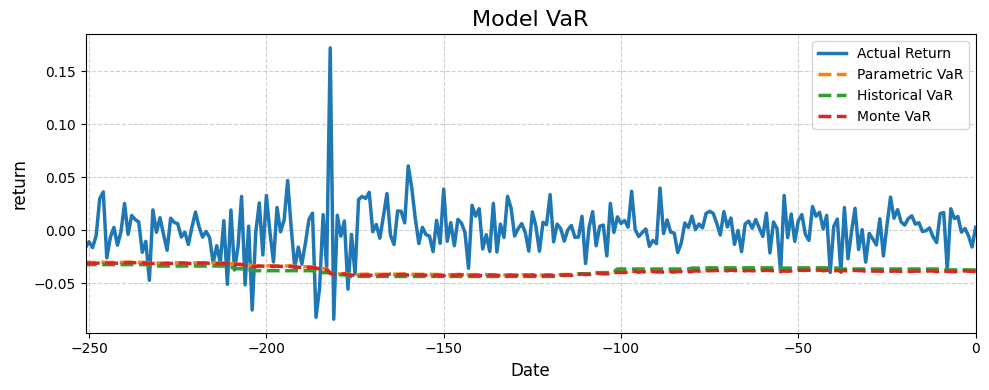

In [ ]:
# Plot
plt.figure(figsize=(10,4))

# Predictions
plt.plot(result_var.index, result_var["Actual Return"], label='Actual Return', linestyle='-', linewidth=2.5)
plt.plot(result_var.index, result_var["Parametric VaR"], label='Parametric VaR', linestyle='--', linewidth=2.5)
plt.plot(result_var.index, result_var["Historical VaR"], label='Historical VaR', linestyle='--', linewidth=2.5)
plt.plot(result_var.index, result_var["Monte VaR"], label='Monte VaR', linestyle='--', linewidth=2.5)

# Labels
plt.title('Model VaR', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('return', fontsize=12)
plt.margins(x=0)

# Legend & grid
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## 12. Validating VaR Models with Kupiec's POF Test (Backtesting)

The `kupiec_test` function performs **backtesting** to evaluate how accurately each of the three VaR models (Parametric, Historical, and Monte Carlo) predicts risk, using the **Kupiec Proportion of Failures (POF) test**, based on the binomial distribution.

---

### 1. Statistical formulation

The test asks whether the **number of times the actual loss was worse than the model's predicted VaR (exceptions, $x$)** is consistent, in a statistically significant sense, with the stated confidence level ($c$).

*   **Null hypothesis ($H_0$):** the model is accurate — the observed exception rate ($p_{hat}$) equals the theoretical rate ($p = 1 - c$)
*   **Alternative hypothesis ($H_1$):** the model is inaccurate (it may underestimate or overestimate risk)

The Likelihood Ratio test statistic ($LR_{pof}$) is:
$$LR_{pof} = -2 \ln \left[ \frac{(1-p)^{N-x} p^x}{(1-\hat{p})^{N-x} \hat{p}^x} \right]$$

---

### 2. Line-by-line breakdown

*   **`x = np.sum(result_test["Actual Return"] < result_test["Model VaR"])`**
    Counts how many times `Actual Return` was less than `Model VaR` (i.e. the actual loss was worse than predicted, since VaR is stored as a negative value in this project)
*   **`p = 1 - confidence`**
    The theoretical exception rate (significance level, $\alpha$). E.g. at 95% confidence ($0.95$), $p$ equals 5% ($0.05$)
*   **`p_hat = x / N`**
    The observed exception rate from the data
*   **`lr_pof = -2 * np.log(...)`**
    The Likelihood Ratio statistic, compared against a Chi-Square distribution with 1 degree of freedom
*   **`Crit = chi2.ppf(1 - p, df=1)`**
    The critical value at significance level $\alpha = p = 1-\text{confidence}$, computed as `chi2.ppf(1-p, df=1)` so it matches the theoretical definition of critical value ($\alpha$-level) directly — reducing the chance that a future reader/editor misinterprets it
*   **`p_value = 1 - chi2.cdf(lr_pof, df=1)`**
    The p-value, used to decide between the hypotheses

---

### 3. Decision rule

Compare **the p-value against the significance level $\alpha$** (not against confidence), so the result maps directly onto standard statistical language without requiring inference:

| Statistical result | Decision | What it means for the model |
| :--- | :--- | :--- |
| **p-value $\ge \alpha$** <br>(equivalently $LR_{pof} \le$ Critical Value) | **Fail to reject $H_0$** | **Model passes:** the number of exceptions is within a statistically acceptable range |
| **p-value $< \alpha$** <br>(equivalently $LR_{pof} >$ Critical Value) | **Reject $H_0$** | **Model fails:** it may underestimate risk (if $x$ is too high) or overestimate risk (if $x$ is too low) |

---
### 4. Application in the following cells
The code compares the results of the three main models, so a risk manager can select the model that best reflects actual risk under the market conditions of that rolling window period.

In [ ]:
def kupiec_test(model_var, actual_return, confidence):
  '''
  Kupiec Proportion-of-Failures (POF) backtest

  '''

  result_test = pd.DataFrame({
      "Model VaR": model_var,
      "Actual Return": actual_return
  })

  x = np.sum(result_test["Actual Return"] < result_test["Model VaR"])
  N = len(model_var)
  p = 1 - confidence          # theoretical exception rate (alpha)
  p_hat = x / N                # observed exception rate

  lr_pof = -2 * np.log((((1-p) ** (N-x)) * (p ** x)) / (((1-p_hat) ** (N-x)) * (p_hat ** x)))
  alpha = p
  Crit = chi2.ppf(1 - alpha, df=1)
  p_value = 1 - chi2.cdf(lr_pof, df=1)

  print(f"LR: {lr_pof:.4f}")
  print(f"Critical Value ({alpha*100:.2f}%): {Crit:.4f}")
  print(f"p-value: {p_value:.4f}")

  if p_value > alpha:
    print("result test: Fail to reject H0 (Pass)")
  else:
    print("result test: reject H0 (Fail)")

In [ ]:
# Parametric VaR
kupiec_test(output_rolling["Parametric VaR"],actual_return["actual_return"],CONFIDENCE)

LR: 0.1583
Critical Value (5.00%): 3.8415
p-value: 0.6907
result test: Fail to reject H0 (Pass)


In [ ]:
# Historical VaR
kupiec_test(output_rolling["Historical VaR"],actual_return["actual_return"],CONFIDENCE)

LR: 0.0305
Critical Value (5.00%): 3.8415
p-value: 0.8613
result test: Fail to reject H0 (Pass)


In [ ]:
# Monte Carlo Simulation
kupiec_test(output_rolling["Monte VaR"],actual_return["actual_return"],CONFIDENCE)

LR: 0.0132
Critical Value (5.00%): 3.8415
p-value: 0.9084
result test: Fail to reject H0 (Pass)
